In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kirtandelwadia/corporate-credit-rating-with-financial-ratios/corporateCreditRatingWithFinancialRatios.csv


# EDA

## overall analysis

In [3]:
df = pd.read_csv('/kaggle/input/datasets/kirtandelwadia/corporate-credit-rating-with-financial-ratios/corporateCreditRatingWithFinancialRatios.csv')

In [4]:
print(df.describe())

                CIK  Binary Rating     SIC Code  Current Ratio  \
count  7.805000e+03    7805.000000  7805.000000    7805.000000   
mean   7.371616e+05       0.653299  4052.576810       1.926313   
std    5.143542e+05       0.475950  1870.848802       1.921651   
min    1.750000e+03       0.000000   100.000000       0.174900   
25%    9.355600e+04       0.000000  2834.000000       1.077300   
50%    8.795260e+05       1.000000  3714.000000       1.496800   
75%    1.091587e+06       1.000000  4931.000000       2.161000   
max    1.748790e+06       1.000000  9997.000000      34.076800   

       Long-term Debt / Capital  Debt/Equity Ratio  Gross Margin  \
count               7805.000000        7805.000000   7805.000000   
mean                   0.452804           0.177349     42.433909   
std                    2.629158          34.456334     23.742020   
min                  -86.363600       -1473.098000    -87.684000   
25%                    0.286500           0.419700     22.453900 

--- Analyzing Target Variables ---


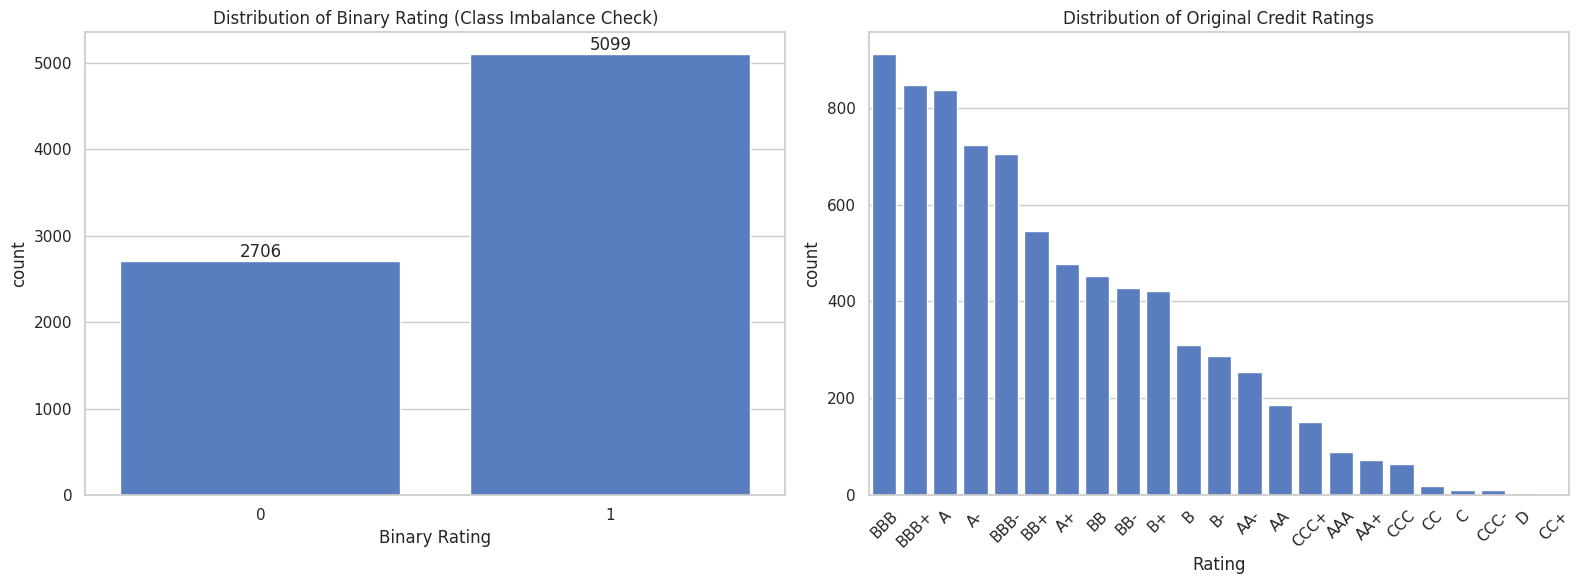

--- Analyzing Corporate Sectors ---


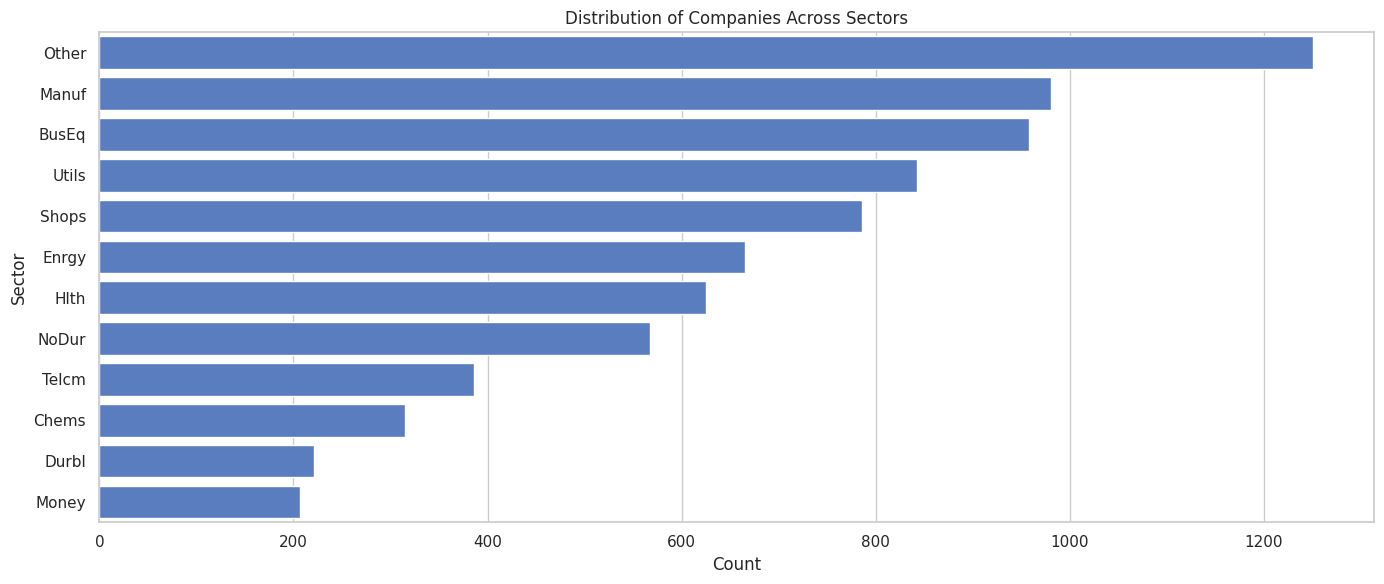

--- Analyzing Financial Ratios (Distributions & Outliers) ---


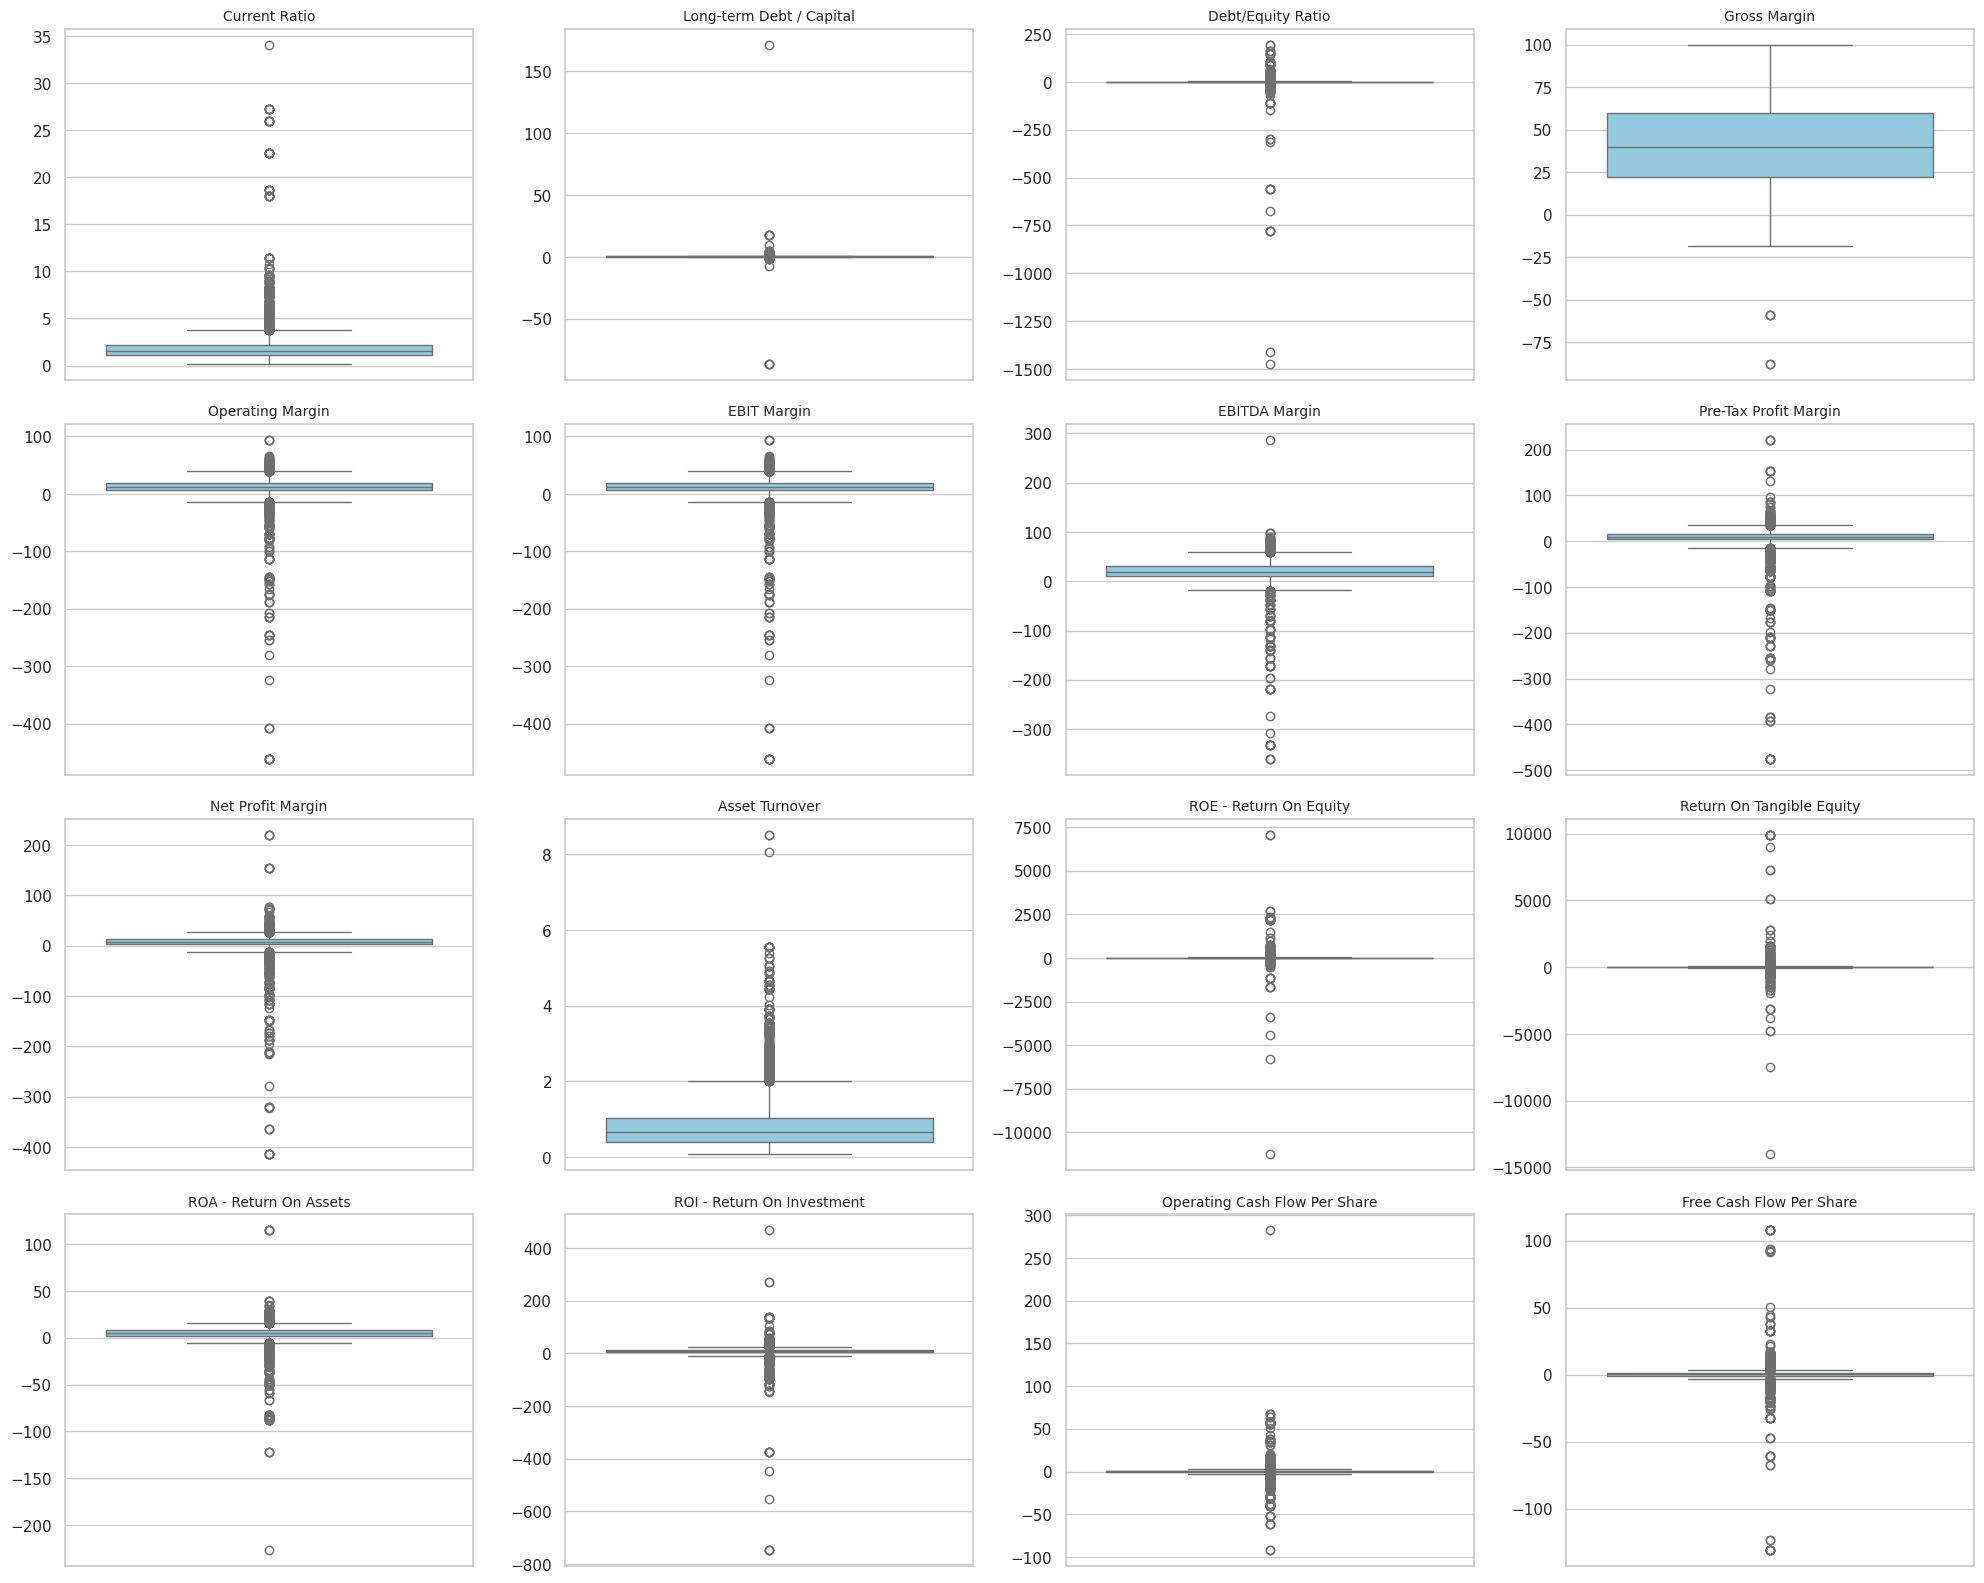

--- Analyzing Multicollinearity (Correlation Matrix) ---


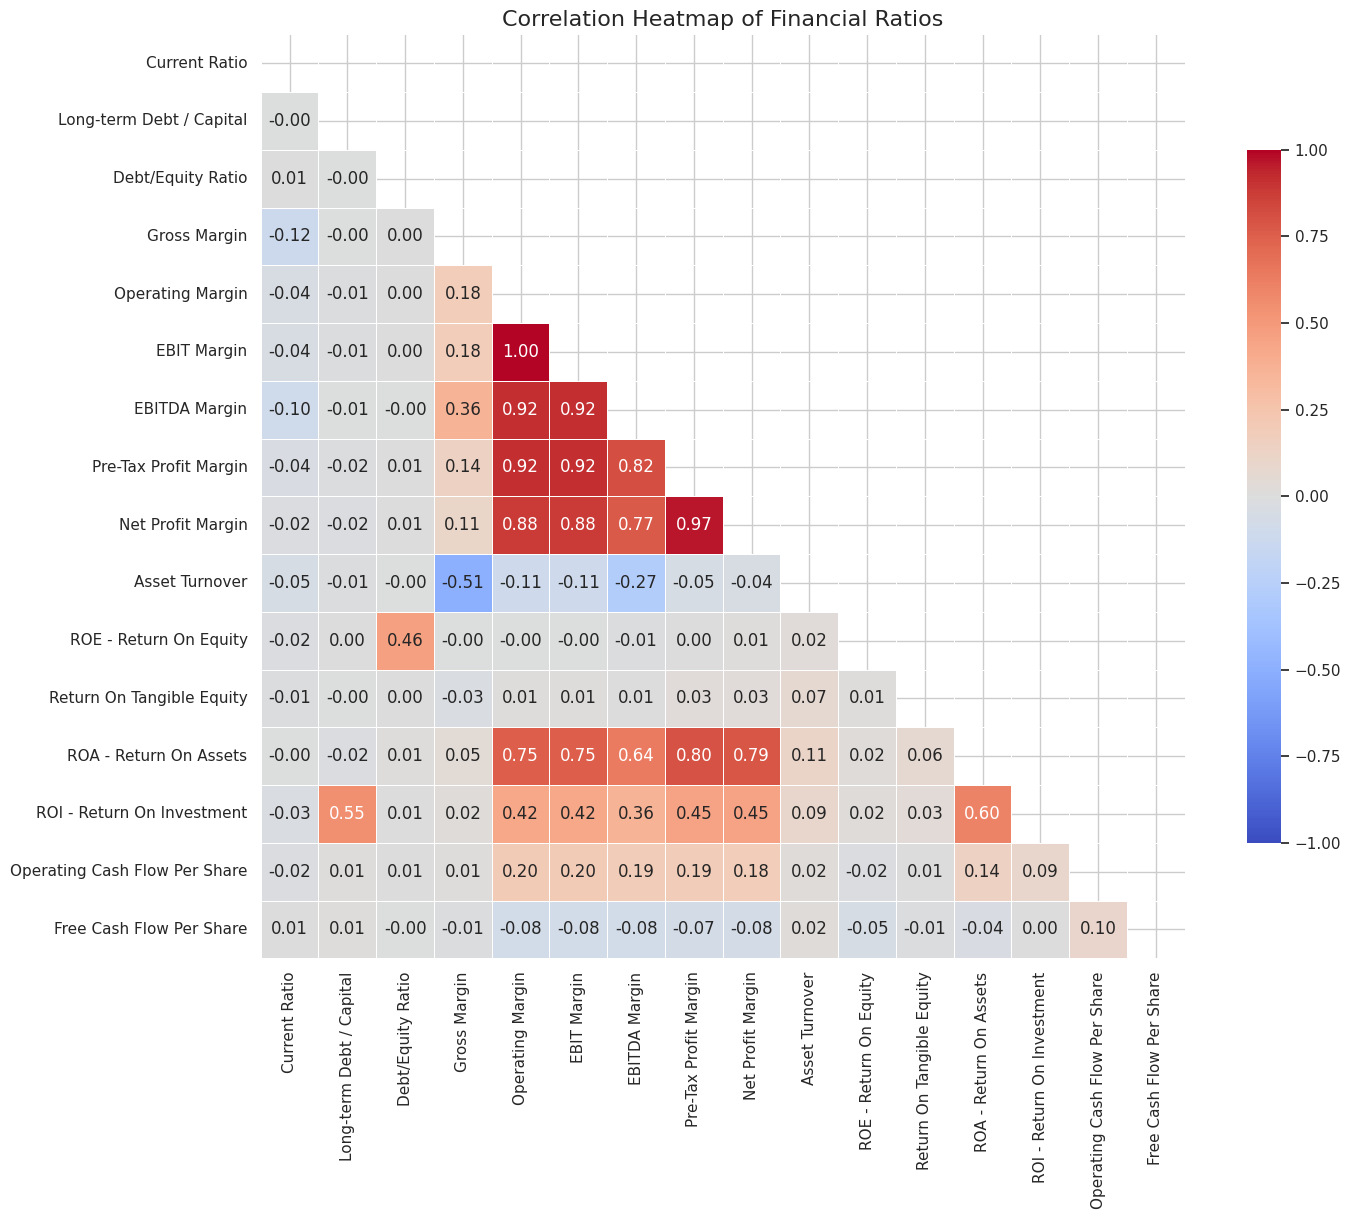

In [5]:
# Import necessary libraries for visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Set the visual style for our plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

# Assuming your dataframe is already loaded as 'df'

# ---------------------------------------------------------
# 1. Target Variable Analysis
# ---------------------------------------------------------
print("--- Analyzing Target Variables ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Binary Rating distribution
sns.countplot(data=df, x='Binary Rating', ax=axes[0])
axes[0].set_title('Distribution of Binary Rating (Class Imbalance Check)')
axes[0].bar_label(axes[0].containers[0])

# Plot original categorical Rating distribution
order = df['Rating'].value_counts().index # Sort by frequency
sns.countplot(data=df, x='Rating', order=order, ax=axes[1])
axes[1].set_title('Distribution of Original Credit Ratings')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Categorical Analysis: Sector Distribution
# ---------------------------------------------------------
print("--- Analyzing Corporate Sectors ---")
plt.figure(figsize=(14, 6))
sns.countplot(data=df, y='Sector', order=df['Sector'].value_counts().index)
plt.title('Distribution of Companies Across Sectors')
plt.xlabel('Count')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Numerical Features: Distribution & Outliers
# ---------------------------------------------------------
print("--- Analyzing Financial Ratios (Distributions & Outliers) ---")

# Define our financial ratio columns (excluding IDs, dates, and target)
# Based on your df.info()
numerical_cols = [
    'Current Ratio', 'Long-term Debt / Capital', 'Debt/Equity Ratio',
    'Gross Margin', 'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
    'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
    'ROE - Return On Equity', 'Return On Tangible Equity',
    'ROA - Return On Assets', 'ROI - Return On Investment',
    'Operating Cash Flow Per Share', 'Free Cash Flow Per Share'
]

# We will plot boxplots to visualize the extreme outliers seen in df.describe()
# Because the scales vary wildly, we plot them individually
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Correlation Analysis
# ---------------------------------------------------------
print("--- Analyzing Multicollinearity (Correlation Matrix) ---")
# Many financial ratios are derived from the same base numbers (e.g., EBIT vs EBITDA)
# Highly correlated features can confuse models and bloat training time.

plt.figure(figsize=(16, 12))
# Calculate correlation matrix using only the numerical ratios
corr_matrix = df[numerical_cols].corr()

# Create a mask for the upper triangle to make it easier to read
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Correlation Heatmap of Financial Ratios', fontsize=16)
plt.show()

--- Analyzing Target Variables ---


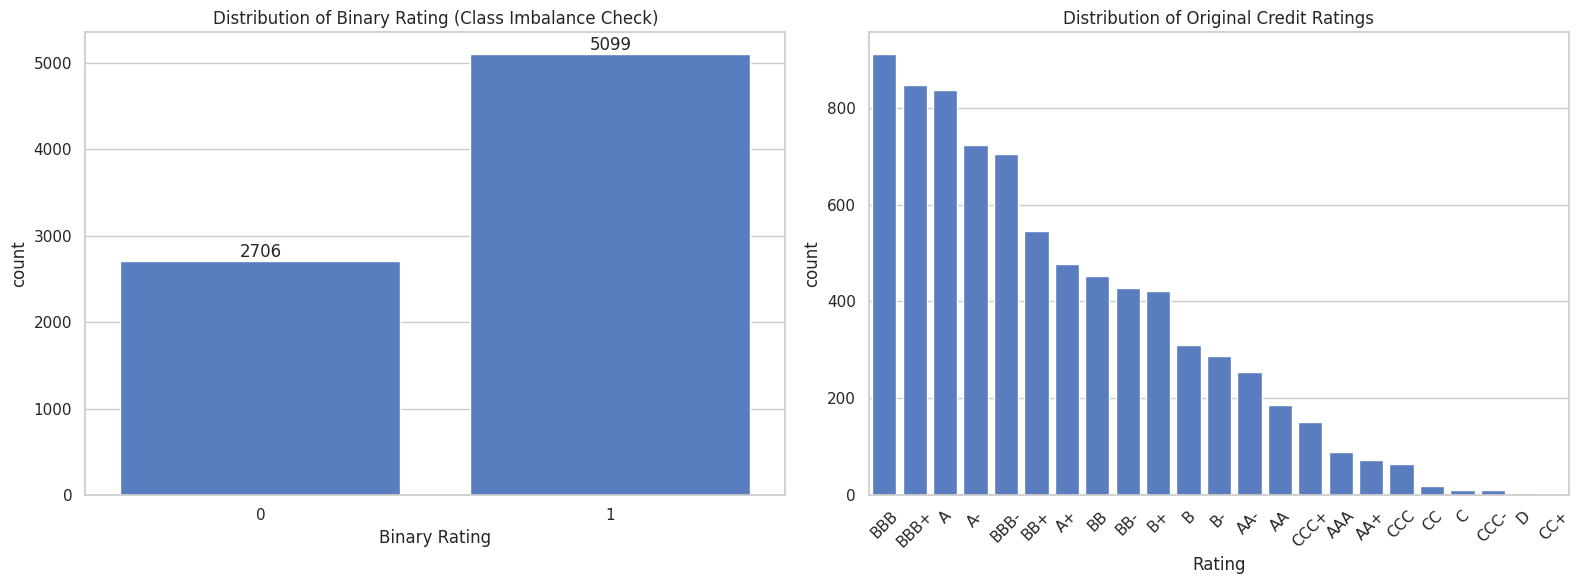

--- Analyzing Corporate Sectors ---


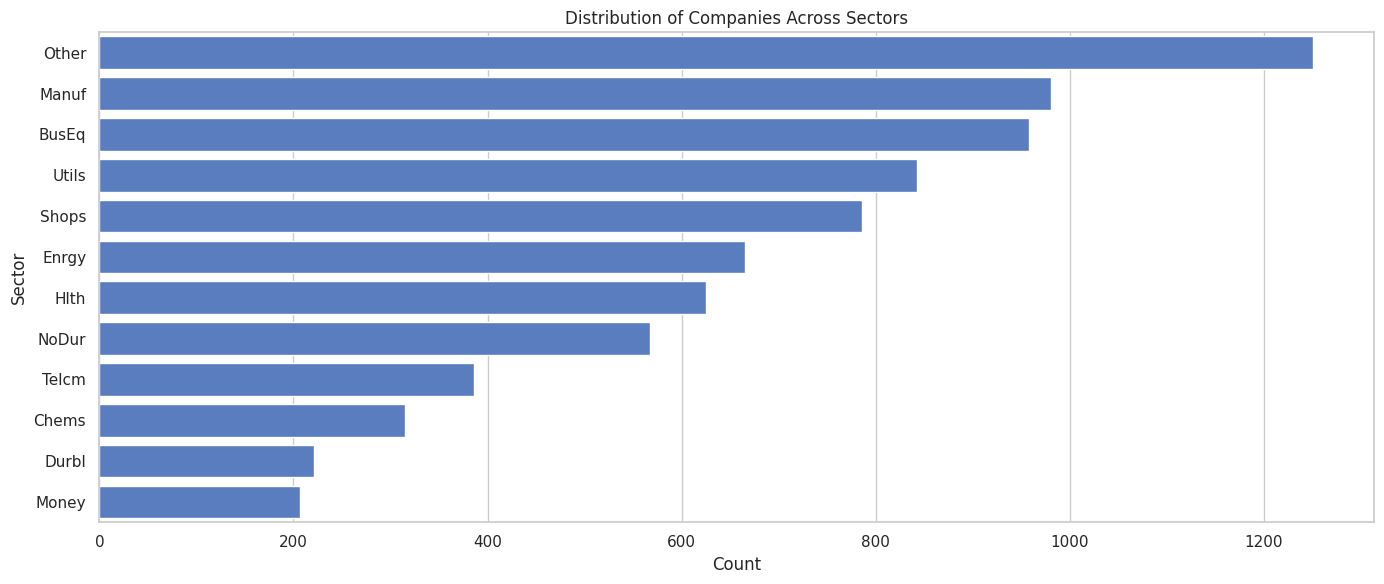

--- Analyzing Financial Ratios & Handling Outliers ---


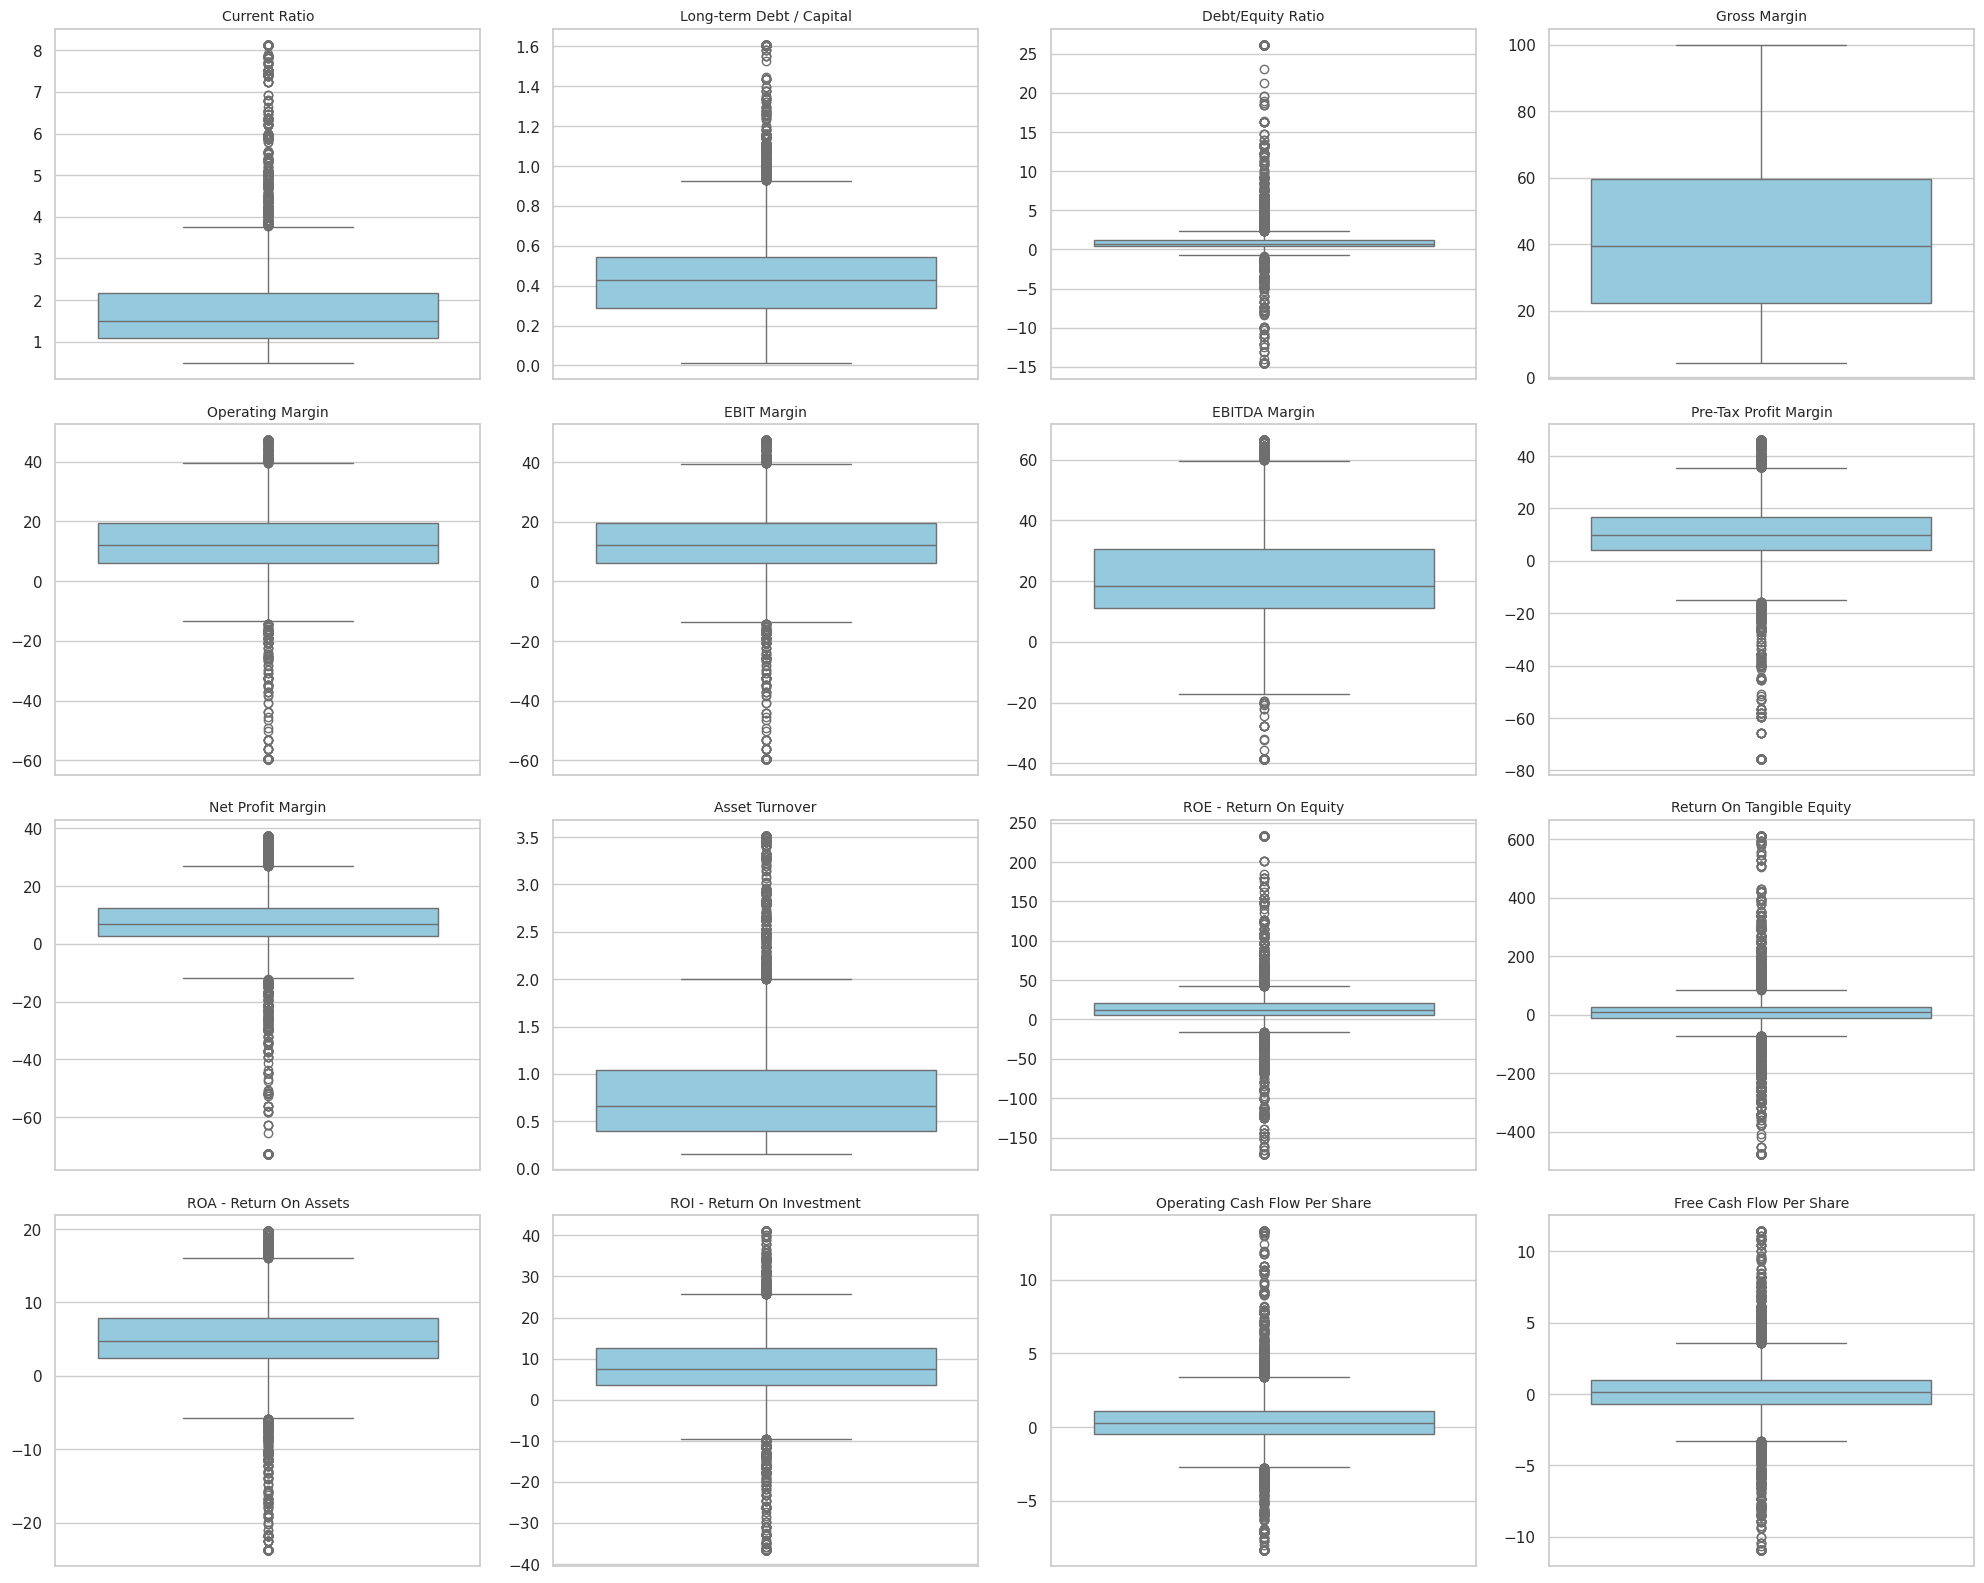

--- Analyzing Multicollinearity (Correlation Matrix & VIF) ---


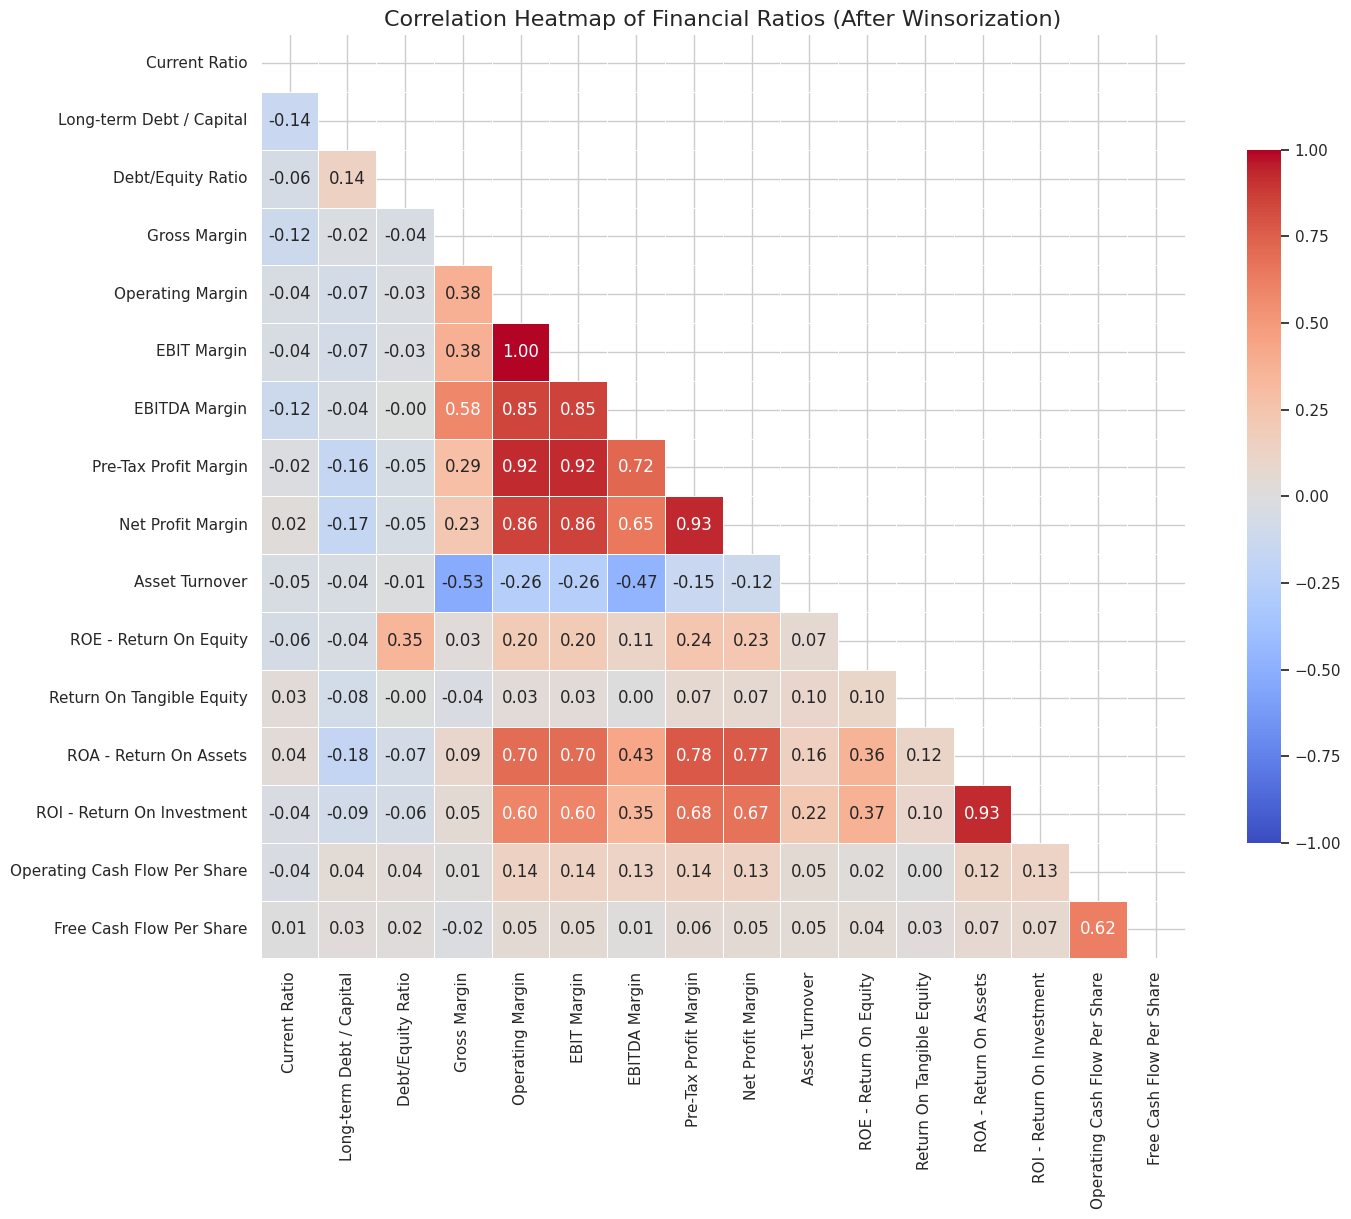


--- Variance Inflation Factor (VIF) ---
                          Feature          VIF
0                     EBIT Margin  1364.136296
1                Operating Margin  1355.298800
2           Pre-Tax Profit Margin    21.745049
3          ROA - Return On Assets    19.378850
4                   EBITDA Margin    16.051856
5      ROI - Return On Investment    13.293215
6               Net Profit Margin    10.338758
7                    Gross Margin     6.130709
8        Long-term Debt / Capital     3.828209
9                  Asset Turnover     2.868442
10                  Current Ratio     2.541274
11  Operating Cash Flow Per Share     1.776068
12       Free Cash Flow Per Share     1.674306
13         ROE - Return On Equity     1.580385
14              Debt/Equity Ratio     1.361157
15      Return On Tangible Equity     1.045813


In [6]:
"""
test laij eda
"""

# Import necessary libraries for visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mstats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set the visual style for our plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

# Assuming your dataframe is already loaded as 'df'

# ---------------------------------------------------------
# 1. Target Variable Analysis
# ---------------------------------------------------------
print("--- Analyzing Target Variables ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Binary Rating distribution
sns.countplot(data=df, x='Binary Rating', ax=axes[0])
axes[0].set_title('Distribution of Binary Rating (Class Imbalance Check)')
axes[0].bar_label(axes[0].containers[0])

# Plot original categorical Rating distribution
order = df['Rating'].value_counts().index # Sort by frequency
sns.countplot(data=df, x='Rating', order=order, ax=axes[1])
axes[1].set_title('Distribution of Original Credit Ratings')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Categorical Analysis: Sector Distribution
# ---------------------------------------------------------
print("--- Analyzing Corporate Sectors ---")
plt.figure(figsize=(14, 6))
sns.countplot(data=df, y='Sector', order=df['Sector'].value_counts().index)
plt.title('Distribution of Companies Across Sectors')
plt.xlabel('Count')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Numerical Features: Distribution & Outlier Handling (Winsorization)
# ---------------------------------------------------------
print("--- Analyzing Financial Ratios & Handling Outliers ---")

numerical_cols = [
    'Current Ratio', 'Long-term Debt / Capital', 'Debt/Equity Ratio',
    'Gross Margin', 'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
    'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
    'ROE - Return On Equity', 'Return On Tangible Equity',
    'ROA - Return On Assets', 'ROI - Return On Investment',
    'Operating Cash Flow Per Share', 'Free Cash Flow Per Share'
]

# Áp dụng Winsorization (cắt 1% giá trị biên) để hạn chế extreme outliers bóp méo boxplot
df_clean = df.copy()
for col in numerical_cols:
    df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.01, 0.01])

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Correlation & VIF Analysis (Multicollinearity Check)
# ---------------------------------------------------------
print("--- Analyzing Multicollinearity (Correlation Matrix & VIF) ---")

plt.figure(figsize=(16, 12))
corr_matrix = df_clean[numerical_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Correlation Heatmap of Financial Ratios (After Winsorization)', fontsize=16)
plt.show()

# Tính Variance Inflation Factor (VIF) để đo lường mức độ phình phương sai
print("\n--- Variance Inflation Factor (VIF) ---")
X = df_clean[numerical_cols].dropna()
vif_data = pd.DataFrame()
vif_data["Feature"] = numerical_cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(numerical_cols))]

print(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))


### print(df.isnull().sum())
"""
clean data !!
clean data !!

"""


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   object 
 1   Corporation                    7805 non-null   object 
 2   Rating                         7805 non-null   object 
 3   Rating Date                    7805 non-null   object 
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   float64
 7   Sector                         7805 non-null   object 
 8   Ticker                         7805 non-null   object 
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   f

In [8]:
df.Corporation.value_counts()

Corporation
TransDigm Inc.                      23
Mondelez International, Inc.        23
Tenet Healthcare Corp.              23
Duke Energy Corporation             22
POSCO                               21
                                    ..
GLOBAL WATER RESOURCES, INC.         1
Global Payments Inc                  1
Global Payments Inc.                 1
HudBay Minerals Inc.                 1
Peabody Energy Corporation (DIP)     1
Name: count, Length: 1377, dtype: int64

## rating agency

In [9]:
df['Rating Agency'].value_counts()

Rating Agency
Egan-Jones Ratings Company            2826
Standard & Poor's Ratings Services    2813
Moody's Investors Service             1636
Fitch Ratings                          477
DBRS                                    26
Japan Credit Rating Agency,Ltd.         22
HR Ratings de Mexico S.A. de C.V.        5
Name: count, dtype: int64

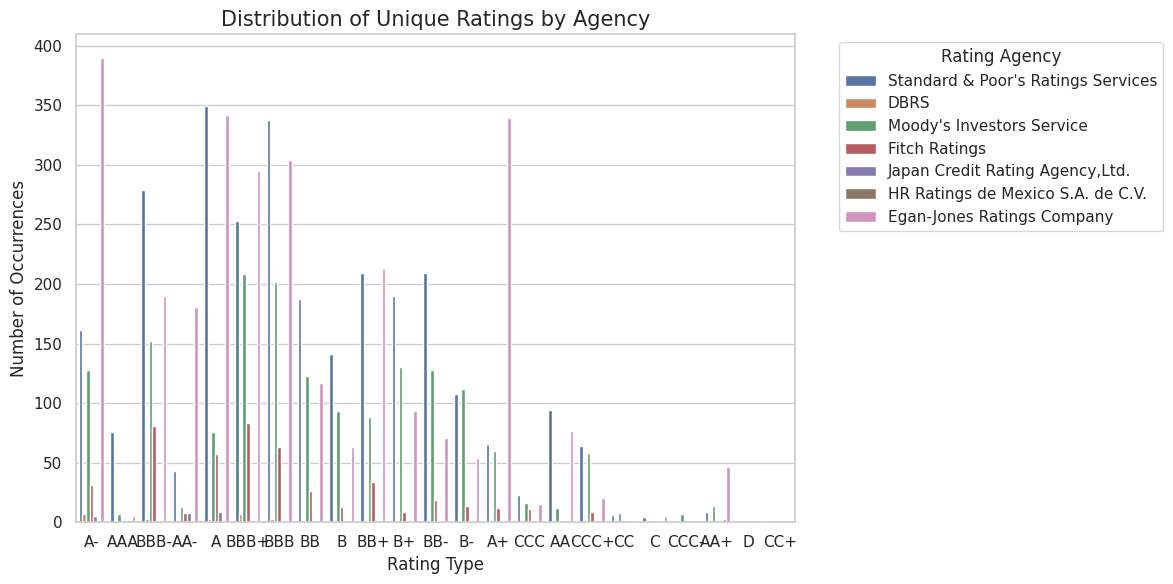

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Rating', hue='Rating Agency')

# 4. Add labels and title
plt.title('Distribution of Unique Ratings by Agency', fontsize=15)
plt.xlabel('Rating Type', fontsize=12)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.legend(title='Rating Agency', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Show the plot
plt.tight_layout()
plt.show()

## "rating" column

In [11]:
# This returns a count of every unique value in the 'Rating' column
rating_distribution = df['Rating'].value_counts()
print(rating_distribution)

Rating
BBB     910
BBB+    846
A       836
A-      722
BBB-    705
BB+     545
A+      478
BB      453
BB-     427
B+      422
B       310
B-      288
AA-     254
AA      185
CCC+    151
AAA      90
AA+      73
CCC      65
CC       18
C        11
CCC-     10
D         5
CC+       1
Name: count, dtype: int64


## if the data imbalance ?

YESSS

In [12]:
import pandas as pd

# Define the mapping from credit rating to 5 risk classes
rating_to_risk = {
    # Lowest Risk (Best credit quality)
    'AAA': 'Lowest Risk',
    'AA+': 'Lowest Risk',
    'AA': 'Lowest Risk',
    'AA-': 'Lowest Risk',
    
    # Low Risk
    'A+': 'Low Risk',
    'A': 'Low Risk',
    'A-': 'Low Risk',
    
    # Medium Risk
    'BBB+': 'Medium Risk',
    'BBB': 'Medium Risk',
    'BBB-': 'Medium Risk',
    
    # High Risk
    'BB+': 'High Risk',
    'BB': 'High Risk',
    'BB-': 'High Risk',
    'B+': 'High Risk',
    'B': 'High Risk',
    'B-': 'High Risk',
    
    # Highest Risk (Worst credit quality, including default)
    'CCC+': 'Highest Risk',
    'CCC': 'Highest Risk',
    'CCC-': 'Highest Risk',
    'CC+': 'Highest Risk',
    'CC': 'Highest Risk',
    'C': 'Highest Risk',
    
    'D': 'IN Default'   # Company is dead / default
}

# Function to map ratings (handles unknown ratings gracefully)
def map_rating_to_risk(rating):
    """Map individual rating to risk class."""
    return rating_to_risk.get(rating, 'Unknown')  # Fallback for any missing rating

# Apply the mapping to your DataFrame
def apply_risk_mapping(df):
    """Add risk class column to DataFrame."""
    df = df.copy()
    df['Rating_Class'] = df['Rating'].apply(map_rating_to_risk)
    return df

# Example usage with your existing DataFrame
#df = pd.read_csv('/kaggle/input/datasets/kirtandelwadia/corporate-credit-rating-with-financial-ratios/corporateCreditRatingWithFinancialRatios.csv')   # or however you load the data
df = apply_risk_mapping(df)

# Verify the distribution of the new classes
print("Risk Class Distribution:")
print(df['Rating_Class'].value_counts())

# Optional: View cross-tabulation with original ratings
print("\nRating to Risk Class Mapping:")
print(pd.crosstab(df['Rating'], df['Rating_Class']))

Risk Class Distribution:
Rating_Class
Medium Risk     2461
High Risk       2445
Low Risk        2036
Lowest Risk      602
Highest Risk     256
IN Default         5
Name: count, dtype: int64

Rating to Risk Class Mapping:
Rating_Class  High Risk  Highest Risk  IN Default  Low Risk  Lowest Risk  \
Rating                                                                     
A                     0             0           0       836            0   
A+                    0             0           0       478            0   
A-                    0             0           0       722            0   
AA                    0             0           0         0          185   
AA+                   0             0           0         0           73   
AA-                   0             0           0         0          254   
AAA                   0             0           0         0           90   
B                   310             0           0         0            0   
B+                 

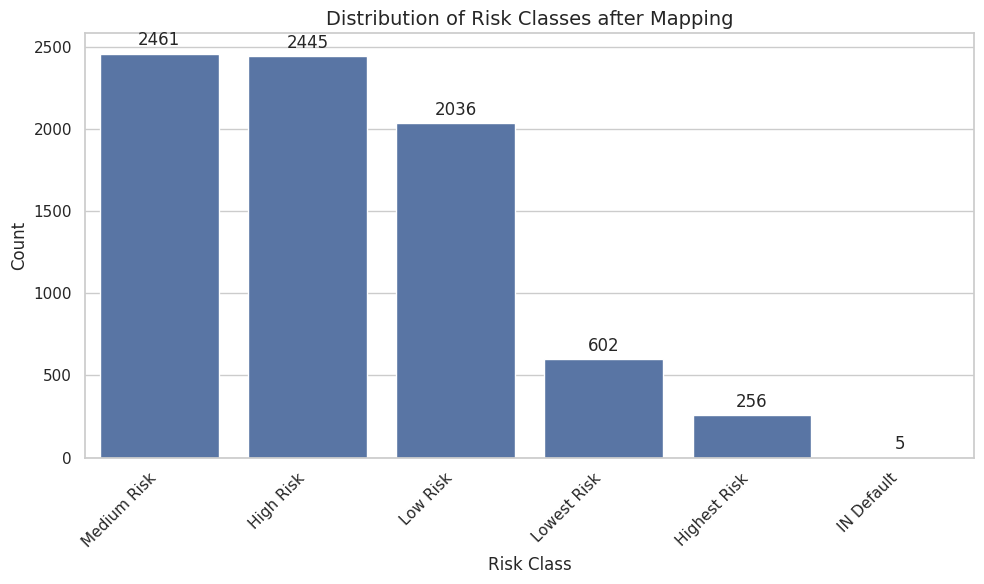

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the new Risk Class
plt.figure(figsize=(10, 6))


sns.countplot(
    x='Rating_Class', 
    data=df, 
    order=df['Rating_Class'].value_counts().index,
    
)

plt.title('Distribution of Risk Classes after Mapping', fontsize=14)
plt.xlabel('Risk Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count labels on top of each bar
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()


## Freatures selection and prepare data


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   object 
 1   Corporation                    7805 non-null   object 
 2   Rating                         7805 non-null   object 
 3   Rating Date                    7805 non-null   object 
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   float64
 7   Sector                         7805 non-null   object 
 8   Ticker                         7805 non-null   object 
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   f

In [25]:
# ---------------------------------------------------------
# Feature Selection: Removing Multicollinearity
# gemiini
# ---------------------------------------------------------
print(f"Original shape: {df.shape}")

# List of highly correlated features identified via heatmap
columns_to_drop = [
    'Operating Margin',       # Correlated 1.00 with EBIT Margin
    'EBIT Margin',            # Correlated 0.92 with EBITDA Margin
    'Pre-Tax Profit Margin'   # Correlated 0.97 with Net Profit Margin
]

# Drop the redundant columns
df_clean = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} redundant features.")
print(f"New shape: {df_clean.shape}")

# Optional: Verify the surviving columns
print("\nRemaining Profitability Margins:")
print([col for col in df_clean.columns if 'Margin' in col])

Original shape: (7805, 26)
Dropped 3 redundant features.
New shape: (7805, 23)

Remaining Profitability Margins:
['Gross Margin', 'EBITDA Margin', 'Net Profit Margin']


In [26]:
df_clean.describe()

,CIK,Binary Rating,SIC Code,Current Ratio,Long-term Debt / Capital,Debt/Equity Ratio,Gross Margin,EBITDA Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
count,7.805000e+03,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000,7805.000000
mean,7.371616e+05,0.653299,4052.576810,1.926313,0.452804,0.177349,42.433909,20.071493,5.995566,0.849843,15.950507,21.481589,4.575705,7.076084,0.479756,0.119491
std,5.143542e+05,0.475950,1870.848802,1.921651,2.629158,34.456334,23.742020,24.380407,24.055577,0.696204,230.592526,462.734075,9.229899,24.382027,6.050626,7.253660
min,1.750000e+03,0.000000,100.000000,0.174900,-86.363600,-1473.098000,-87.684000,-360.816900,-414.824800,0.068400,-11258.210000,-14023.260000,-226.442500,-745.454500,-91.330200,-130.665800
25%,9.355600e+04,0.000000,2834.000000,1.077300,0.286500,0.419700,22.453900,11.162100,2.637100,0.399500,6.022800,-12.233900,2.391900,3.692600,-0.448500,-0.723700
50%,8.795260e+05,1.000000,3714.000000,1.496800,0.427200,0.752800,39.635400,18.304500,6.938900,0.661200,12.500000,10.564100,4.767500,7.440800,0.237800,0.133500
75%,1.091587e+06,1.000000,4931.000000,2.161000,0.542200,1.211600,59.641700,30.661600,12.366700,1.038800,20.515700,26.894100,7.881300,12.515100,1.088800,0.997800
max,1.748790e+06,1.000000,9997.000000,34.076800,171.500000,194.375000,100.000000,286.493500,219.390300,8.503900,7038.461000,9882.979000,114.716900,466.666700,282.192100,107.737700


In [27]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   object 
 1   Corporation                    7805 non-null   object 
 2   Rating                         7805 non-null   object 
 3   Rating Date                    7805 non-null   object 
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   float64
 7   Sector                         7805 non-null   object 
 8   Ticker                         7805 non-null   object 
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   f